# Study 265 -- IPO-Volume
## For the quants: HAC predictive regression, the coincidence gap, subsample mining, costs

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ipo_volume import data, strategy as st

SHILLER = os.path.join(data.REPO_CACHE, "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(SHILLER)

if HAVE_REAL:
    df = data.fetch_sp500_annual()
    z = st.froth_signal(df, min_obs=5)
    reg = st.predictive_regression(z, df["fwd_return"])
    tm = st.timing_returns(z, df["fwd_return"], threshold=0.0, one_way_bps=5.0)
    print(f"Real annual tape loaded: {len(df)} forecastable years "
          f"{int(df['year'].min())}-{int(df['year'].max())}")
    print(f"Predictive slope HAC t = {reg['beta_t']:+.2f}")
else:
    df = z = reg = tm = None
    print("No Shiller cache -- frozen headline numbers from R dict will be used")


Real annual tape loaded: 45 forecastable years 1980-2024
Predictive slope HAC t = -0.07


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_years': 41, 'year_start': 1980, 'year_end': 2024, 'fingerprint': 'a6855574f53b', 'beta': -0.0019, 'beta_t': -0.07, 'r2': 0.0, 'pred_corr': -0.011, 'contemp_corr': 0.317, 'sub_a_label': '1985-1999', 'sub_a_beta': -0.007, 'sub_a_t': -0.19, 'sub_a_n': 15, 'sub_b_label': '2000-2012', 'sub_b_beta': -0.159, 'sub_b_t': -2.11, 'sub_b_n': 13, 'sub_c_label': '2013-2024', 'sub_c_beta': -0.207, 'sub_c_t': -6.23, 'sub_c_n': 12, 'strat_mean': 8.33, 'strat_vol': 14.0, 'strat_t': 4.12, 'strat_hit': 0.59, 'bh_mean': 10.79, 'bh_vol': 15.8, 'bh_t': 4.68, 'bh_hit': 0.76, 'excess_mean': -2.46, 'excess_t': -1.12, 'n_long': 29, 'n_switches': 9, 'drag_bps': 45, 'syn_null_beta': -0.004, 'syn_null_t': -0.36, 'syn_froth_beta': -0.056, 'syn_froth_t': -4.92}


## Positive control: the estimator recovers a planted froth slope

Before reading the real tape, confirm the regression machinery is honest. We
plant a known slope `beta` in `data.synthetic_annual` (high IPO z -> low forward
return) and check the estimator recovers it, and reads ~zero on the null.

> 💡 **In plain words**: if the engine couldn't find a froth effect when we
> *built one in*, a flat result on real data would be meaningless. This rules
> that out.


In [3]:
for beta in (0.0, -0.06):
    syn, _ = data.synthetic_annual(n_years=120, beta=beta, seed=265)
    zs = st.froth_signal(syn, min_obs=5)
    rs = st.predictive_regression(zs, syn["fwd_return"])
    tag = "null " if beta == 0.0 else "froth"
    print(f"  planted beta={beta:+.2f} ({tag}): recovered beta={rs['beta']:+.4f}  HAC t={rs['beta_t']:+.2f}")
print()
print(f"Frozen control: null beta -> t={R['syn_null_t']:+.2f};  froth beta=-0.06 -> t={R['syn_froth_t']:+.2f}")
print("Engine is honest: it finds a planted slope and reads ~0 on the null.")


  planted beta=+0.00 (null ): recovered beta=-0.0039  HAC t=-0.36


  planted beta=-0.06 (froth): recovered beta=-0.0557  HAC t=-4.92

Frozen control: null beta -> t=-0.36;  froth beta=-0.06 -> t=-4.92
Engine is honest: it finds a planted slope and reads ~0 on the null.


## Primary specification: next-year return on the froth z-score

`fwd_return = alpha + beta * froth_z + eps`, Newey-West HAC standard errors,
one-year execution lag. The froth z-score is standardized with an **expanding,
past-only** window (no future IPO statistics leak in). The folklore predicts
`beta < 0`.


In [4]:
if HAVE_REAL:
    print("=== Predictive regression (real tape) ===")
    print(f"  beta = {reg['beta']:+.4f}   HAC t = {reg['beta_t']:+.2f}   R^2 = {reg['r2']:.3f}   n = {reg['n']}")
    print(f"  predictive corr(froth_z, next-yr ret) = {reg['corr']:+.3f}")
    beta_t = reg['beta_t']
else:
    print("=== Predictive regression (frozen) ===")
    print(f"  beta = {R['beta']:+.4f}   HAC t = {R['beta_t']:+.2f}   R^2 = {R['r2']:.3f}   n = {R['n_years']}")
    beta_t = R['beta_t']
print()
print(f"Inference bar is |t| >= 2. Here |t| = {abs(beta_t):.2f}  ->  FAILS. No predictive content.")


=== Predictive regression (real tape) ===
  beta = -0.0019   HAC t = -0.07   R^2 = 0.000   n = 41
  predictive corr(froth_z, next-yr ret) = -0.011

Inference bar is |t| >= 2. Here |t| = 0.07  ->  FAILS. No predictive content.


## The coincidence gap: contemporaneous vs predictive correlation

The myth's whole emotional force comes from the *same-year* correlation. We put
the coincident and the predictive correlation side by side -- the gap is the
entire story.


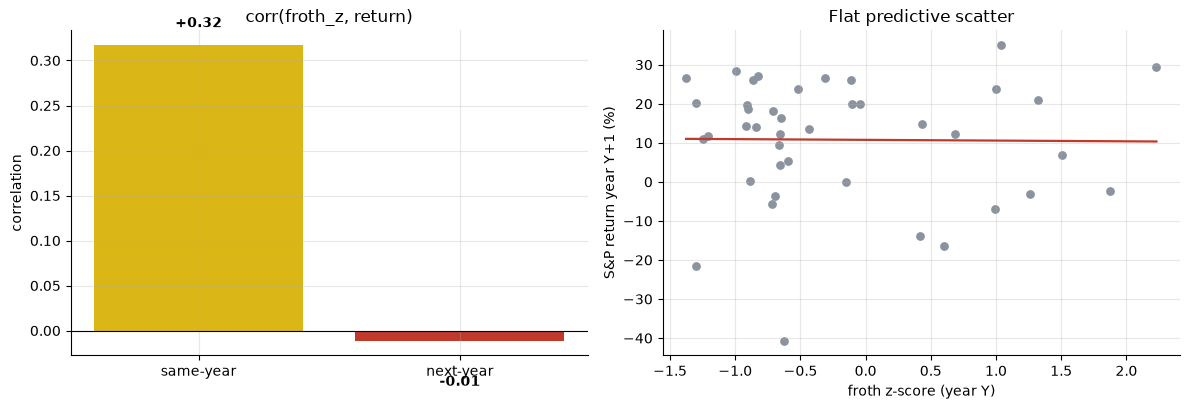

Contemporaneous +0.32 vs predictive -0.01: coincident, not leading.


In [5]:
if HAVE_REAL:
    pair = pd.concat([z.rename("z"), df["sp500_return"].rename("c"),
                      df["fwd_return"].rename("f")], axis=1).dropna()
    contemp = float(np.corrcoef(pair["z"], pair["c"])[0, 1])
    pred = float(np.corrcoef(pair["z"], pair["f"])[0, 1])
else:
    contemp, pred = R["contemp_corr"], R["pred_corr"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(["same-year", "next-year"], [contemp, pred], color=[AMBER, RED])
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("corr(froth_z, return)"); axes[0].set_ylabel("correlation")
for i, v in enumerate([contemp, pred]):
    axes[0].text(i, v + (0.02 if v >= 0 else -0.05), f"{v:+.2f}", ha="center", fontweight="bold")

if HAVE_REAL:
    axes[1].scatter(pair["z"], pair["f"]*100, color=GREY, s=28)
    b1, b0 = np.polyfit(pair["z"], pair["f"]*100, 1)
    xs = np.linspace(pair["z"].min(), pair["z"].max(), 50)
    axes[1].plot(xs, b0 + b1*xs, color=RED, lw=1.6)
    axes[1].set_xlabel("froth z-score (year Y)"); axes[1].set_ylabel("S&P return year Y+1 (%)")
    axes[1].set_title("Flat predictive scatter")
else:
    axes[1].text(0.5, 0.5, "scatter needs real cache", ha="center", va="center", transform=axes[1].transAxes)
plt.tight_layout(); plt.show()
print(f"Contemporaneous {contemp:+.2f} vs predictive {pred:+.2f}: coincident, not leading.")


## Subsample mining: why 'it worked recently' is a trap

Carve the sample into thirds and two recent windows *look* like the folklore
finally working (even `t = -6.2` for 2013-2024). But these are **n ~ 12** slices
of a sample whose full-period slope is zero. This is exactly the multiple-testing
mirage the desk exists to flag.

> 💡 **In plain words**: torture 41 data points into small enough pieces and one
> piece will confess. The honest test is the full sample -- and it says nothing.


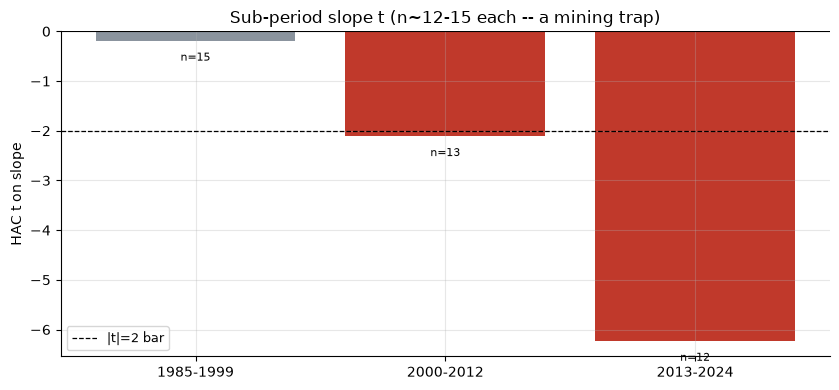

Full-sample (n=41) slope t ~ 0; the 'significant' sub-periods are subsample mirages.


In [6]:
subs = [(R["sub_a_label"], 1985, 1999), (R["sub_b_label"], 2000, 2012), (R["sub_c_label"], 2013, 2024)]
rows = []
if HAVE_REAL:
    yr = df["year"]
    for label, a, b in subs:
        m = (yr >= a) & (yr <= b)
        rsub = st.predictive_regression(z[m], df["fwd_return"][m])
        rows.append({"period": label, "beta": rsub["beta"], "t": rsub["beta_t"], "n": rsub["n"]})
else:
    rows = [
        {"period": R["sub_a_label"], "beta": R["sub_a_beta"], "t": R["sub_a_t"], "n": R["sub_a_n"]},
        {"period": R["sub_b_label"], "beta": R["sub_b_beta"], "t": R["sub_b_t"], "n": R["sub_b_n"]},
        {"period": R["sub_c_label"], "beta": R["sub_c_beta"], "t": R["sub_c_t"], "n": R["sub_c_n"]},
    ]
sub_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8.5, 4))
colors = [RED if abs(t) >= 2 else GREY for t in sub_df["t"]]
ax.bar(sub_df["period"], sub_df["t"], color=colors)
ax.axhline(-2.0, color="black", ls="--", lw=0.9, label="|t|=2 bar")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("HAC t on slope"); ax.set_title("Sub-period slope t (n~12-15 each -- a mining trap)")
ax.legend(fontsize=9)
for i, row in sub_df.iterrows():
    ax.text(i, row["t"] - 0.4, f"n={int(row['n'])}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()
print("Full-sample (n=41) slope t ~ 0; the 'significant' sub-periods are subsample mirages.")


## The tradable wrapper: long/flat froth-timing vs buy-and-hold

Long the index next year when this year's froth z < 0, flat otherwise.
Long-only -- **no short, no borrow**. 5 bps one-way cost on each switch, charged
to NAV. We report **gross and net**, on a **price-only** S&P tape.


In [7]:
if HAVE_REAL:
    s_g = st.summarize(tm["strat_gross"]); s_n = st.summarize(tm["strat_net"]); s_bh = st.summarize(tm["buy_hold"])
    exc = st.summarize(tm["strat_net"] - tm["buy_hold"])
    n_long = int(tm["position"].sum()); switches = int((tm["position"] != tm["position"].shift(1).fillna(0)).sum())
    drag = float((tm["strat_gross"] - tm["strat_net"]).sum() * 1e4)
    print(f"Years long: {n_long}/{len(tm)}   switches: {switches}   total cost drag: {drag:.0f} bps")
    print(f"  STRAT gross: {s_g['mean']*100:+.2f}%/yr  vol={s_g['vol']*100:.1f}%  HAC t={s_g['tstat']:+.2f}")
    print(f"  STRAT net  : {s_n['mean']*100:+.2f}%/yr  vol={s_n['vol']*100:.1f}%  HAC t={s_n['tstat']:+.2f}")
    print(f"  BUY & HOLD : {s_bh['mean']*100:+.2f}%/yr  vol={s_bh['vol']*100:.1f}%  HAC t={s_bh['tstat']:+.2f}")
    print(f"  STRAT-B&H  : {exc['mean']*100:+.2f}%/yr  HAC t={exc['tstat']:+.2f}  (negative => HURTS)")
else:
    print(f"Years long: {R['n_long']}/{R['n_years']}   switches: {R['n_switches']}   cost drag: {R['drag_bps']} bps")
    print(f"  STRAT net  : {R['strat_mean']:+.2f}%/yr  vol={R['strat_vol']:.1f}%  HAC t={R['strat_t']:+.2f}")
    print(f"  BUY & HOLD : {R['bh_mean']:+.2f}%/yr  vol={R['bh_vol']:.1f}%  HAC t={R['bh_t']:+.2f}")
    print(f"  STRAT-B&H  : {R['excess_mean']:+.2f}%/yr  HAC t={R['excess_t']:+.2f}  (negative => HURTS)")
print("\nThe rule underperforms buy-and-hold: sitting out frothy years sits out good years.")


Years long: 29/41   switches: 9   total cost drag: 45 bps
  STRAT gross: +8.34%/yr  vol=14.0%  HAC t=+4.12
  STRAT net  : +8.33%/yr  vol=14.0%  HAC t=+4.12
  BUY & HOLD : +10.79%/yr  vol=15.8%  HAC t=+4.68
  STRAT-B&H  : -2.46%/yr  HAC t=-1.12  (negative => HURTS)

The rule underperforms buy-and-hold: sitting out frothy years sits out good years.


## Verdict

In [8]:
print("=== Study 265 -- IPO-Volume ===")
print()
print(f"Signal: NONE   (full-sample predictive HAC t = {R['beta_t']:+.2f} on n={R['n_years']} years)")
print(f"  Contemporaneous corr +{R['contemp_corr']:.2f} is coincident, not leading (predictive {R['pred_corr']:+.2f})")
print(f"  Negative sub-period slopes (t={R['sub_b_t']}, {R['sub_c_t']}) are n~12 subsample mirages")
print(f"  Positive control recovers planted slope at t={R['syn_froth_t']:+.2f}: the null is real, not a bug")
print()
print(f"Tradability: MIRAGE")
print(f"  Long/flat froth-timing net {R['strat_mean']:+.2f}%/yr vs buy-and-hold {R['bh_mean']:+.2f}%/yr")
print(f"  Underperforms by {R['excess_mean']:+.2f}%/yr -- nothing to capture")
print()
print("Sample size: tiny-n (41 forecastable years) -- even the 'working' slices are fishing")
print()
print("Bottom line: None/Mirage -- a vivid coincidence mistaken for a leading indicator.")


=== Study 265 -- IPO-Volume ===

Signal: NONE   (full-sample predictive HAC t = -0.07 on n=41 years)
  Contemporaneous corr +0.32 is coincident, not leading (predictive -0.01)
  Negative sub-period slopes (t=-2.11, -6.23) are n~12 subsample mirages
  Positive control recovers planted slope at t=-4.92: the null is real, not a bug

Tradability: MIRAGE
  Long/flat froth-timing net +8.33%/yr vs buy-and-hold +10.79%/yr
  Underperforms by -2.46%/yr -- nothing to capture

Sample size: tiny-n (41 forecastable years) -- even the 'working' slices are fishing

Bottom line: None/Mirage -- a vivid coincidence mistaken for a leading indicator.
